In [1]:
using PyPlot # Plotting using matplotlib Python library
using DelimitedFiles # Reading and writing files (e.g. txt)

using Plots # Plotting using Julia library. i use this for the animations as it is easier than PyPlot
using Plots.PlotMeasures # For setting the size of the plots
using LaTeXStrings # For LaTeX in plots with Julia

using Random
using Distributions

using Glob

include("IBM_Allee_lib.jl") # The self-written library for the IBM

IBM_save_all (generic function with 1 method)

# Steady states

In [2]:
L = 30.0                     # System size
N = Int(L^2)                # Initial number of particles

P = rand(Float64, (2, N)) * L .- L / 2

σ_c = 0.5
σ_p = 0.5
σ_d = 0.3
p = 0.0
c = 0.05

d = 1
f = 1

t_max = 300.0

results = Dict()

for coupling in ["low_competition", "high_competition", "high_facilitation", "low_facilitation"]

    γ_c = 1.05
    γ_p = 1.1

    if coupling == "low_competition"

        γ_c = 1.05 / 1.6 #1.52

    elseif coupling == "high_competition"

        γ_c = 1.05

    elseif coupling == "high_facilitation"

        γ_p = 1.1 * 2.2

    elseif coupling == "low_facilitation"

        γ_p = 1.1

    end

    periods = [Inf]

    total_rates = zeros(Float64, 2)
    constants = [γ_c, σ_c, γ_p, σ_p, σ_d, c, p, d, f]

    params = Parameters(constants, total_rates, L)

    # build Variables in struct-of-arrays form
    x = copy(P[1, :])
    y = copy(P[2, :])

    vars = Variables(
        x,
        y,
        zeros(Float64, N),   # D2
        zeros(Float64, N),   # P
        zeros(Float64, N),   # D
        N,
        periods
    )

    # run
    @time N_t, t_arr = IBM(t_max, vars, params);

    results[coupling] = (N_t, t_arr)

end

 11.343018 seconds (25.74 M allocations: 6.562 GiB, 6.31% gc time, 36.72% compilation time: 94% of which was recompilation)
  0.045951 seconds (79.97 k allocations: 21.348 MiB, 6.89% gc time)
 11.380219 seconds (17.03 M allocations: 6.463 GiB, 4.80% gc time)
  0.042280 seconds (77.87 k allocations: 20.944 MiB, 2.07% gc time)


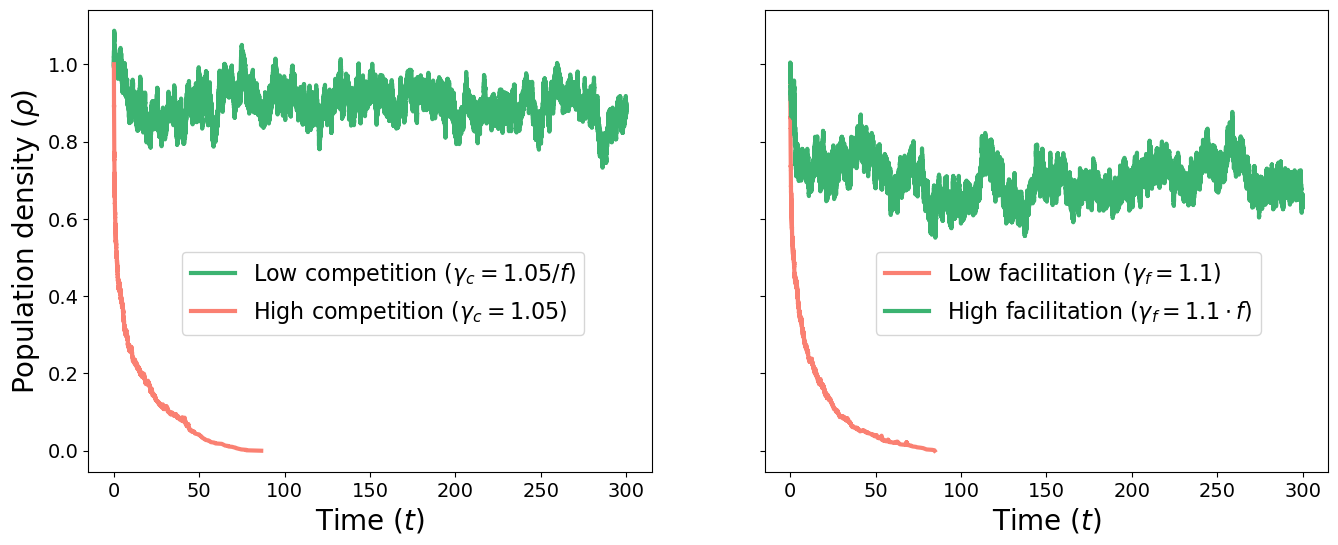

In [3]:
fig, ax = plt.subplot_mosaic(
    """
    AB
    """,
    figsize=(8 * 2, 6),
    sharex=true,
    sharey=true,)

letters = ["A", "B"]

N_t_low_comp, t_arr_low_comp = results["low_competition"]
N_t_high_comp, t_arr_high_comp = results["high_competition"]
N_t_high_fac, t_arr_high_fac = results["high_facilitation"]
N_t_low_fac, t_arr_low_fac = results["low_facilitation"]

ax["A"].plot(
    t_arr_low_comp,
    N_t_low_comp ./ L^2,
    label=L"Low competition ($\gamma_c = 1.05 / f$)",
    color="mediumseagreen",
    linewidth=3,
)

ax["A"].plot(
    t_arr_high_comp,
    N_t_high_comp ./ L^2,
    label=L"High competition ($\gamma_c = 1.05$)",
    color="salmon",
    linewidth=3,
)

ax["A"].legend(fontsize=16, bbox_to_anchor=(0.9, 0.5))

ax["B"].plot(
    t_arr_low_fac,
    N_t_low_fac ./ L^2,
    label=L"Low facilitation ($\gamma_f = 1.1$)",
    color="salmon",
    linewidth=3,
)

ax["B"].plot(
    t_arr_high_fac,
    N_t_high_fac ./ L^2,
    label=L"High facilitation ($\gamma_f = 1.1 \cdot f$)",
    color="mediumseagreen",
    linewidth=3,
)

ax["B"].legend(fontsize=16, bbox_to_anchor=(0.9, 0.5))

ax["A"].set_ylabel(L"Population density $(\rho)$", fontsize=20)

for letter in letters

    ax[letter].set_xlabel(L"Time $(t)$", fontsize=20)

    ax[letter].tick_params(labelsize=14)

end

# plt.savefig("Figures/example_steady_states_allee.pdf", dpi=300, bbox_inches="tight")

# Comparison of precipitation coupled to competition vs facilitation

In [4]:
results = Dict()

for coupling in ["competition", "facilitation"]

    L = 30.0                     # System size
    N = Int(L^2)                 # Initial number of particles

    P = rand(Float64, (2, N)) * L .- L / 2

    γ_c = 1.05
    γ_p = 1.1
    σ_c = 0.5
    σ_p = 0.5
    σ_d = 0.3
    p = 0.0
    c = 0.05

    if coupling == "competition"
        f = 1.6 # 1.52
        d = 50.0
    elseif coupling == "facilitation"
        f = 2.2
        d = 25.0
    else
        error("Unknown coupling type: $coupling")
    end

    t_max = 300.0

    l = 0.0
    λ = 0.1

    distribution = Exponential(1.0 / λ)
    periods = Float64[]

    while l < t_max * 2
        # l += rand(distribution)      # stochastic
        l += 1.0 / λ                     # deterministic
        push!(periods, l)
        l += d
    end

    # periods = [Inf] #Uncomment this line to disable switching

    total_rates = zeros(Float64, 2)
    constants = [γ_c, σ_c, γ_p, σ_p, σ_d, c, p, d, f]

    params = Parameters(constants, total_rates, L)

    # build Variables in struct-of-arrays form
    x = copy(P[1, :])
    y = copy(P[2, :])

    vars = Variables(
        x,
        y,
        zeros(Float64, N),   # D2
        zeros(Float64, N),   # P
        zeros(Float64, N),   # D
        N,
        periods
    )

    # run
    @time N_t, t_arr = IBM(t_max, vars, params; coupling=coupling);

    results[coupling] = (N_t, t_arr)

end

  2.971790 seconds (5.26 M allocations: 1.638 GiB, 8.67% gc time, 0.16% compilation time)
  3.381640 seconds (6.86 M allocations: 1.974 GiB, 2.83% gc time)


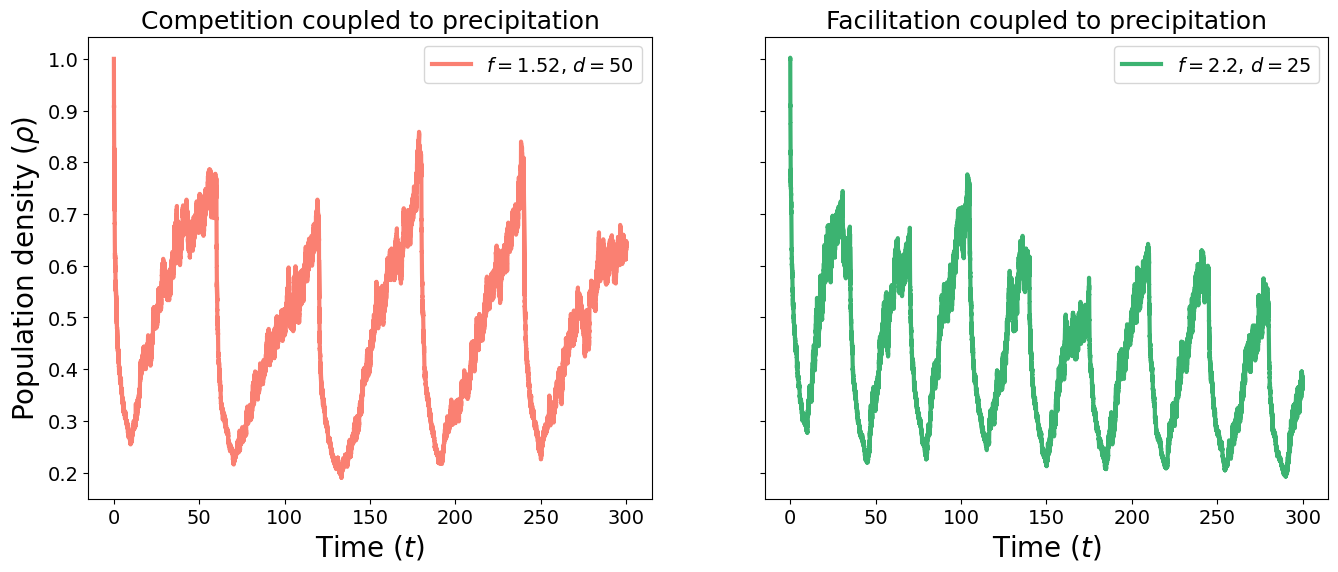

In [5]:
fig, ax = plt.subplot_mosaic(
    """
    AB
    """,
    figsize=(8 * 2, 6),
    sharex=true,
    sharey=true,)

letters = ["A", "B"]

N_t_comp, t_arr_comp = results["competition"]
N_t_fac, t_arr_fac = results["facilitation"]

ax["A"].plot(
    t_arr_comp,
    N_t_comp ./ L^2,
    label=L"$f=1.52$, $d=50$",
    color="salmon",
    linewidth=3,
)

ax["A"].set_title("Competition coupled to precipitation", fontsize=18)

ax["A"].legend(fontsize=14)

ax["B"].plot(
    t_arr_fac,
    N_t_fac ./ L^2,
    label=L"$f=2.2$, $d=25$",
    color="mediumseagreen",
    linewidth=3,
)

ax["B"].set_title("Facilitation coupled to precipitation", fontsize=18)

ax["B"].legend(fontsize=14)

ax["A"].set_ylabel(L"Population density $(\rho)$", fontsize=20)

for letter in letters
    ax[letter].set_xlabel(L"Time $(t)$", fontsize=20)

    ax[letter].tick_params(labelsize=14)

end

# plt.savefig("Figures/coupling_competition_vs_facilitation_allee.pdf", dpi=300, bbox_inches="tight")

# Single simulation

In [6]:
L = 30.0                     # System size
N = Int(L^2)                 # Initial number of particles

P = rand(Float64, (2, N)) * L .- L / 2

γ_c = 1.05
γ_p = 1.1
σ_c = 0.5
σ_p = 0.5
σ_d = 0.3
p = 0.0
c = 0.05

coupling = "facilitation"

if coupling == "competition"
    f = 1.52
    d = 50.0
elseif coupling == "facilitation"
    f = 2.2
    d = 25.0
else
    error("Unknown coupling type: $coupling")
end

t_max = 300.0

l = 0.0
λ = 0.1

distribution = Exponential(1.0 / λ)
periods = Float64[]

while l < t_max * 2
    # l += rand(distribution)      # stochastic
    l += 1.0 / λ                     # deterministic
    push!(periods, l)
    l += d
end

# periods = [Inf] #Uncomment this line to disable switching

total_rates = zeros(Float64, 2)
constants = [γ_c, σ_c, γ_p, σ_p, σ_d, c, p, d, f]

params = Parameters(constants, total_rates, L)

# build Variables in struct-of-arrays form
x = copy(P[1, :])
y = copy(P[2, :])

vars = Variables(
    x,
    y,
    zeros(Float64, N),   # D2
    zeros(Float64, N),   # P
    zeros(Float64, N),   # D
    N,
    periods
)

# run
@time N_t, t_arr = IBM(t_max, vars, params; coupling=coupling);

  3.040548 seconds (15.01 M allocations: 2.004 GiB, 10.70% gc time, 110.75% compilation time: 100% of which was recompilation)


## Plot

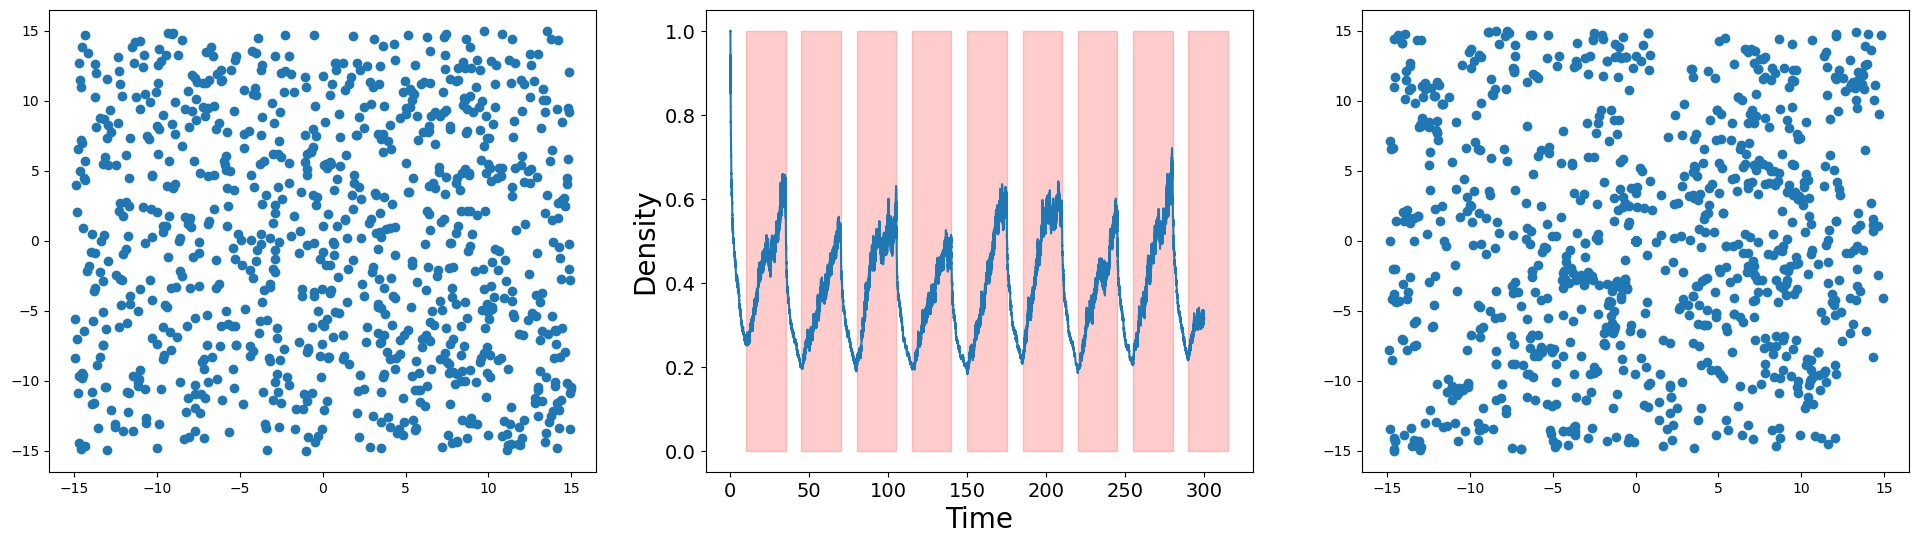

(-16.5, 16.5)

In [7]:
N_t_light = N_t[1:1:end]
t_arr_light = t_arr[1:1:end]

fig, ax = plt.subplot_mosaic("""ABC""", figsize=(8*3, 6))

ax["A"].scatter(P[1,:], P[2,:])

ax["A"].set_ylim(-L / 2 * 1.1, L / 2 * 1.1)
ax["A"].set_xlim(-L / 2 * 1.1, L / 2 * 1.1)

ax["B"].plot(t_arr_light, N_t_light / L^2)

ax["B"].set_ylabel("Density", fontsize=20)
ax["B"].set_xlabel("Time", fontsize=20)

ax["B"].tick_params(labelsize=14)

for period in periods

    if period > t_arr[(N_t .> 0)][end]
        break
    end

    ax["B"].fill_betweenx([0, 1], period, period + d, color="red", alpha=0.2)

end

# ax["B"].set_ylim(-0.05, 1.1)

ax["C"].scatter(x, y)

ax["C"].set_ylim(-L/2 * 1.1, L/2 * 1.1)
ax["C"].set_xlim(-L/2 * 1.1, L/2 * 1.1)

#plt.savefig("Figures/example_no_switching_high_competition.png", dpi=300)

# Simulate for animation

In [8]:
save_at = 1.0 # Save every save_at time steps (approx)

folder = "Example_simulation_allee"

# In the folder does not exist, create it
if !isdir(folder)
    mkdir(folder)
else
    println("Warning: folder $folder already exists. Files will be removed.")
    println("You have 10 seconds to cancel if you don't want this.")
    sleep(10) # Wait 10 seconds to give the user time to cancel if needed
    rm(folder, recursive=true)
    mkdir(folder)
    println("Folder $folder has been cleared.")
end

L = 30.0 # System size (length of the square)

N = Int(L^2) # Initial number of particles

P = rand(Float64, (2, N)) * L .- L/2 # Uniform initial distribution
#P = randn(Float64, (2, N)) * 4 / 2 # Gaussian initial distribution

dist = zeros(N, N) # Initialize distance matrix

γ_c = 1.05 # Competition strength
γ_p = 1.1  # Proliferation (cooperation) strength

σ_c = 0.5 # Competition noise
σ_p = 0.5 # Proliferation (cooperation) noise
σ_d = 0.3 # Diffusion (in offspring) noise

p = 0.0 # Proliferation (cooperation) rate
c = 0.05 # Competition rate

coupling = "facilitation"

if coupling == "competition"
    f = 1.52
    d = 50.0
elseif coupling == "facilitation"
    f = 2.2
    d = 25.0
else
    error("Unknown coupling type: $coupling")
end

t_max = 200.0 # Time at which the simulation will finish.

# Create switching times
l = 0 
λ = 0.1 # Switching rate

distribution = Exponential(1.0/λ) # Exponential distribution for the duration of the periods

periods = []

while l < t_max*2 # Generate periods until the end of the simulation (and a little more for safety)

    # l += rand(distribution)
    l += 1.0/λ

    append!(periods, l)

    l += d

end

periods = convert(Array{Float64,1}, periods) # Convert to float array

# periods = [Inf] #Uncomment this line to disable switching

total_rates = zeros(Float64, 2)
constants = [γ_c, σ_c, γ_p, σ_p, σ_d, c, p, d, f]

params = Parameters(constants, total_rates, L)

# build Variables in struct-of-arrays form
x = copy(P[1, :])
y = copy(P[2, :])

vars = Variables(
    x,
    y,
    zeros(Float64, N),   # D2
    zeros(Float64, N),   # P
    zeros(Float64, N),   # D
    N,
    periods
)

# Simulate
@time IBM_save_all(t_max, vars, params; folder=folder, save_at=save_at, coupling=coupling);

You have 10 seconds to cancel if you don't want this.
Folder Example_simulation_allee has been cleared.
  2.477194 seconds (4.78 M allocations: 1.101 GiB, 12.09% gc time, 6.88% compilation time)


## Create animation

In [9]:
folder = "Example_simulation_allee" # Same name as before

# Read all files from folder
filenames = glob("P*.txt", folder)

N_t = readdlm(string(folder, "/N_t.txt")) # Read the number of particles
t_arr = readdlm(string(folder, "/t_res.txt")) # Read the time array

# Split . and _ to get the time of each file
ts = []
for filename in filenames

    name = split(filename, "/")[2] # Get the file name without the path

    t_i = split(name, "_")[2][1:end-4]

    # as float
    t_i = parse(Float64, t_i)

    append!(ts, t_i)

end

ts = sort(ts) # Sort the times

anim = @animate for t in ts

    i = findfirst(x -> x == t, ts) # Find the index of the time

    P = readdlm(string(folder, "/P_", t, ".txt"))

    # Plot initial frame
    p1 = Plots.plot(t_arr[1:i], N_t[1:i] / L^2, xlabel=L"t", ylabel=L"\rho", legend=false, ylim=(0, 2), linewidth=5, titlefont=25,
        tickfontsize=14, guidefontsize=25, legendfontsize=16, title=L"$\rho(t)$", size=(800, 600), framestyle=:box, grid=false, dpi=300)

    p2 = Plots.scatter(P[1, :], P[2, :], xlabel=L"x", ylabel=L"y", legend=false, ylim=(-L / 2, L / 2), xlim=(-L / 2, L / 2), markersize=5, tickfontsize=14,
        guidefontsize=25, legendfontsize=16, title=L"$\vec{r}(t)$", titlefont=25, size=(800, 600), framestyle=:box, grid=false, dpi=300)

    # subplot
    Plots.plot(p1, p2, layout=(1, 2), size=(800 * 2, 600), dpi=300, margin=7mm, left_margin=10mm, right_margin=10mm, top_margin=10mm, bottom_margin=10mm)

end

# save anim as gif
#gif(anim, string("Switching_", folder, ".gif"), fps=10)

# save as mp4
mp4(anim, string(folder, ".mp4"), fps=10)

[ Info: Saved animation to /home/alex/IMPORTANT/Alle Effect/Example_simulation_allee.mp4


Plots.AnimatedGif("/home/alex/IMPORTANT/Alle Effect/Example_simulation_allee.mp4")